In [1]:
import numpy as np
from scipy.spatial import ConvexHull
import os, json, math


In [2]:
MP_A = {'pelvis':0, 'left_hip':1, 'right_hip':2, 'left_knee':4, 'right_knee':5,
        'left_ankle':7, 'right_ankle':8, 'neck':12,
        'left_shoulder':16, 'right_shoulder':17,
        'left_elbow':18, 'right_elbow':19,
        'left_wrist':20, 'right_wrist':21}

MP_B = {'pelvis':0, 'left_hip':1, 'right_hip':2, 'left_knee':3, 'right_knee':4,
        'left_ankle':5, 'right_ankle':6, 'neck':12,
        'left_shoulder':13, 'right_shoulder':14,
        'left_elbow':15, 'right_elbow':16,
        'left_wrist':17, 'right_wrist':18}

In [3]:
# def orth_slice_along_segment(vertices, p0, p1, t=0.5, radius=0.08, tol=0.007):
#     """
#     برش مقطع عمود بر محور اندام (برای بازو/ران).
#     p0->p1: محور اندام؛ t∈[0,1] موقعیت نسبت به p0؛ radius شعاع لوله؛ tol ضخامت برش.
#     خروجی: محیط مقطع (متر)، یا NaN.
#     """
#     v = p1 - p0
#     nv = np.linalg.norm(v)
#     if nv < 1e-6:
#         return np.nan
#     v = v / nv
#     c = p0 + t * (p1 - p0)
#
#     X = vertices - c            # [N,3]
#     proj = X @ v                # مؤلفه روی محور
#     ortho = X - np.outer(proj, v)
#     dist = np.linalg.norm(ortho, axis=1)
#
#     # لولهٔ اطراف محور
#     tube = dist < radius
#     if not np.any(tube):
#         return np.nan
#
#     # برش نازک عمود بر محور
#     slab = np.abs(proj[tube]) < tol
#     pts = (vertices[tube])[slab]
#     if pts.shape[0] < 3:
#         return np.nan
#
#     # صفحهٔ عمود (u,w)
#     a = np.array([1.0, 0.0, 0.0])
#     if abs(a @ v) > 0.9:
#         a = np.array([0.0, 1.0, 0.0])
#     u = np.cross(v, a); u /= np.linalg.norm(u)
#     w = np.cross(v, u)
#
#     rel = pts - c
#     pts2 = np.stack([rel @ u, rel @ w], axis=1)
#     return perimeter_convex(pts2)

def orth_slice_along_segment(vertices, p0, p1, t=0.5, radius=0.08, tol=0.007):
    """برش مقطع عمود بر محور اندام (برای بازو/ران)."""
    v = p1 - p0
    nv = np.linalg.norm(v)
    if nv < 1e-6: return np.nan
    v = v / nv
    c = p0 + t * (p1 - p0)
    X = vertices - c
    proj = X @ v
    ortho = X - np.outer(proj, v)
    dist = np.linalg.norm(ortho, axis=1)
    tube = dist < radius
    if not np.any(tube): return np.nan
    slab = np.abs(proj[tube]) < tol
    pts = (vertices[tube])[slab]
    if pts.shape[0] < 3: return np.nan
    a = np.array([1.0,0.0,0.0])
    if abs(a @ v) > 0.9: a = np.array([0.0,1.0,0.0])
    u = np.cross(v,a); u /= np.linalg.norm(u)
    w = np.cross(v,u)
    rel = pts - c
    pts2 = np.stack([rel @ u, rel @ w], axis=1)
    return perimeter_convex(pts2)

In [4]:
def outseam_cm_from_map(joints, vertices, mp):
    waist_y = 0.5*(joints[mp["left_hip"],1] + joints[mp["right_hip"],1]) + 0.02
    ankle_y = float(min(joints[mp["left_ankle"],1], joints[mp["right_ankle"],1]))
    ground_y = ankle_y - 0.03
    return float(max(0.0, (waist_y - ground_y)) * 100.0)

In [5]:
# def choose_joint_map_auto(joints, vertices):
#     def score(mp):
#         s = sleeve_len_cm_from_map(joints, mp)
#         o = outseam_cm_from_map(joints, vertices, mp)
#         bad = 0
#         if not (40 <= s <= 90):  bad += 1
#         if not (80 <= o <= 120): bad += 1
#         s_err = 0 if 40 <= s <= 90 else min(abs(s-40), abs(s-90))
#         o_err = 0 if 80 <= o <= 120 else min(abs(o-80), abs(o-120))
#         return - (bad*1000 + s_err + o_err), s, o
#     cand = []
#     for mp in (MP_A, MP_B):
#         sc, s, o = score(mp)
#         cand.append((sc, mp, s, o))
#     cand.sort(key=lambda x: -x[0])
#     best = cand[0]
#     return best[1], best[2], best[3]

def choose_joint_map_auto(joints, vertices):
    def score(mp):
        s = sleeve_len_cm_from_map(joints, mp)
        o = outseam_cm_from_map(joints, vertices, mp)
        bad = 0
        if not (40 <= s <= 90):  bad += 1
        if not (80 <= o <= 120): bad += 1
        s_err = 0 if 40 <= s <= 90 else min(abs(s-40), abs(s-90))
        o_err = 0 if 80 <= o <= 120 else min(abs(o-80), abs(o-120))
        return - (bad*1000 + s_err + o_err), s, o
    cand = []
    for mp in (MP_A, MP_B):
        sc, s, o = score(mp)
        cand.append((sc, mp, s, o))
    cand.sort(key=lambda x: -x[0])
    best = cand[0]
    return best[1], best[2], best[3]

In [6]:
# def choose_joint_map_smart(joints):
#     # نگاشت نسخه‌ی B را فعلاً اجبار می‌کنیم
#     return {
#         'pelvis':0, 'left_hip':1, 'right_hip':2, 'left_knee':3, 'right_knee':4,
#         'left_ankle':5, 'right_ankle':6, 'neck':12,
#         'left_shoulder':13, 'right_shoulder':14,
#         'left_elbow':15, 'right_elbow':16,
#         'left_wrist':17, 'right_wrist':18,
#     }



    # def sleeve_len_cm_from_map(joints, mp):
    #     L = np.linalg.norm(joints[mp["left_shoulder"]]-joints[mp["left_elbow"]]) + \
    #         np.linalg.norm(joints[mp["left_elbow"]]-joints[mp["left_wrist"]])
    #     R = np.linalg.norm(joints[mp["right_shoulder"]]-joints[mp["right_elbow"]]) + \
    #         np.linalg.norm(joints[mp["right_elbow"]]-joints[mp["right_wrist"]])
    #     return float(np.nanmean([L, R]) * 100.0)

def sleeve_len_cm_from_map(joints, mp):
    L = np.linalg.norm(joints[mp["left_shoulder"]]-joints[mp["left_elbow"]]) + \
        np.linalg.norm(joints[mp["left_elbow"]]-joints[mp["left_wrist"]])
    R = np.linalg.norm(joints[mp["right_shoulder"]]-joints[mp["right_elbow"]]) + \
        np.linalg.norm(joints[mp["right_elbow"]]-joints[mp["right_wrist"]])
    return float(np.nanmean([L, R]) * 100.0)

def plausible_sleeve(cm):  # 40–90 cm
    return 40.0 <= cm <= 90.0

    s_a = sleeve_len_cm_from_map(mp_a)
    s_b = sleeve_len_cm_from_map(mp_b)

    if plausible_sleeve(s_a) and not plausible_sleeve(s_b):
        return mp_a
    if plausible_sleeve(s_b) and not plausible_sleeve(s_a):
        return mp_b
    # اگر هر دو معقول یا هر دو نامعقول: mp_a را پیش‌فرض بگیر
    return mp_a


In [7]:
def body_height_y(vertices):
    """ارتفاع بدن روی محور y (عمودی)."""
    return float(vertices[:, 1].max() - vertices[:, 1].min())

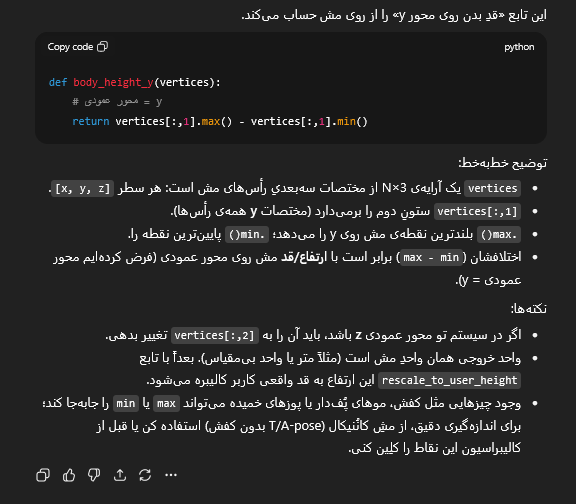

In [8]:
def rescale_to_user_height(vertices, joints, user_height_m, width_scale=1.0):
    """
    اسکیل به قد واقعی؛ در صورت نیاز می‌توان عرض بدن را هم مقیاس کرد.
    width_scale=1.0 یعنی بدون تغییر؛ اگر پهنای بدن زیاد بود، 0.5~0.7 پیشنهاد می‌شود.
    """
    h = body_height_y(vertices)
    s = user_height_m / max(h, 1e-6)
    vertices = vertices * s
    joints = joints * s

    if abs(width_scale - 1.0) > 1e-6:
        vertices = vertices.copy()
        vertices[:, [0, 2]] *= float(width_scale)

    return vertices, joints, s

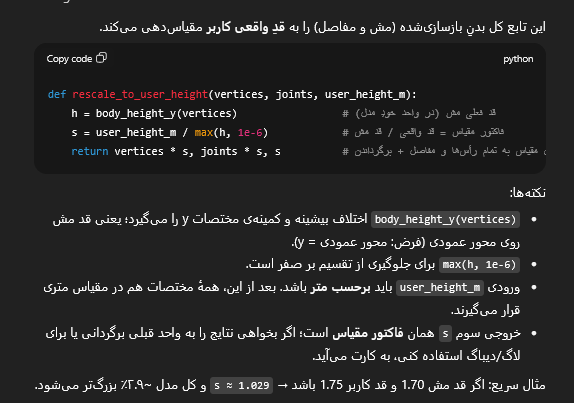

In [9]:
# def slice_points(vertices, y0, tol=0.0075):
#     """
#     برش مش در ارتفاع y0؛ tol حدود 7.5mm بعد از مقیاس واقعی
#     """
#     y = vertices[:,1]  # محور عمودی
#     mask = np.abs(y - y0) < tol
#     # انتخاب دو محور دیگر برای مقطع افقی
#     pts = vertices[mask][:, [0, 2]]  # X و Z
#     if pts.shape[0] < 3:
#         return np.empty((0,2))
#     return pts - pts.mean(axis=0)  # مرکزدهی برای پایداری محیط

def slice_points(vertices, y0, tol=0.0075):
    y = vertices[:,1]
    mask = np.abs(y - y0) < tol
    pts = vertices[mask][:, [0,2]]
    if pts.shape[0] < 3:
        return np.empty((0,2))
    return pts - pts.mean(axis=0)


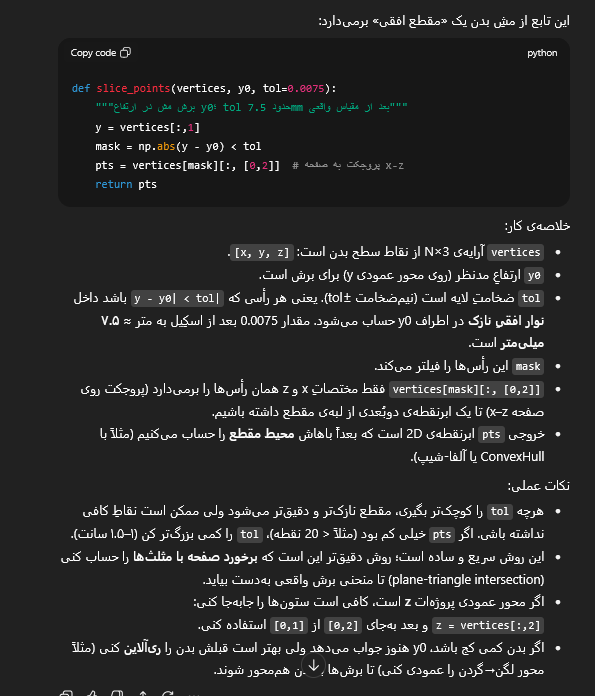
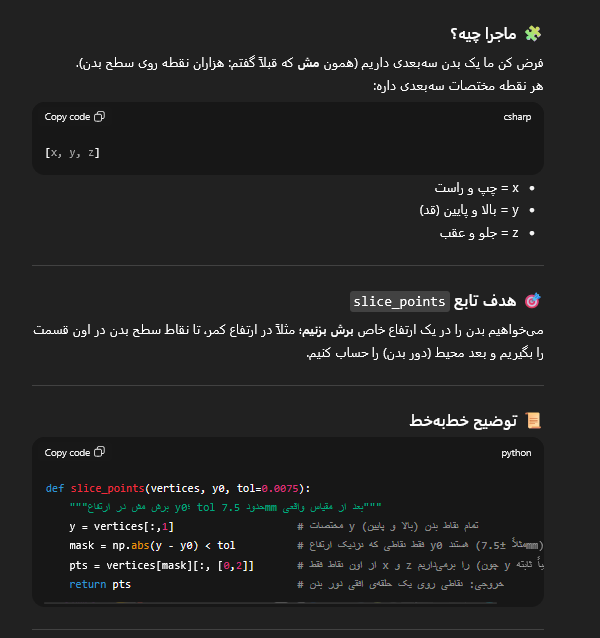
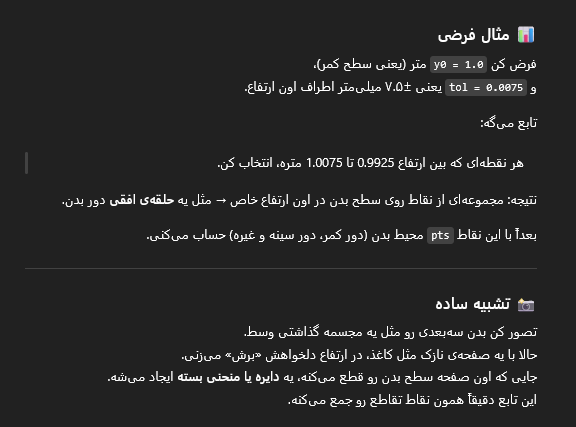

In [10]:
# def perimeter_convex(pts):
#     if len(pts) < 3:
#         return np.nan
#     try:
#         hull = ConvexHull(pts)
#     except Exception:
#         return np.nan
#     P = 0.0
#     for i in range(len(hull.vertices)):
#         a = pts[hull.vertices[i]]
#         b = pts[hull.vertices[(i+1)%len(hull.vertices)]]
#         P += np.linalg.norm(a-b)
#     return float(P)

def perimeter_convex(pts):
    if len(pts) < 3:
        return np.nan
    try:
        hull = ConvexHull(pts)
    except Exception:
        return np.nan
    P = 0.0
    for i in range(len(hull.vertices)):
        a = pts[hull.vertices[i]]
        b = pts[hull.vertices[(i+1)%len(hull.vertices)]]
        P += np.linalg.norm(a-b)
    return float(P)


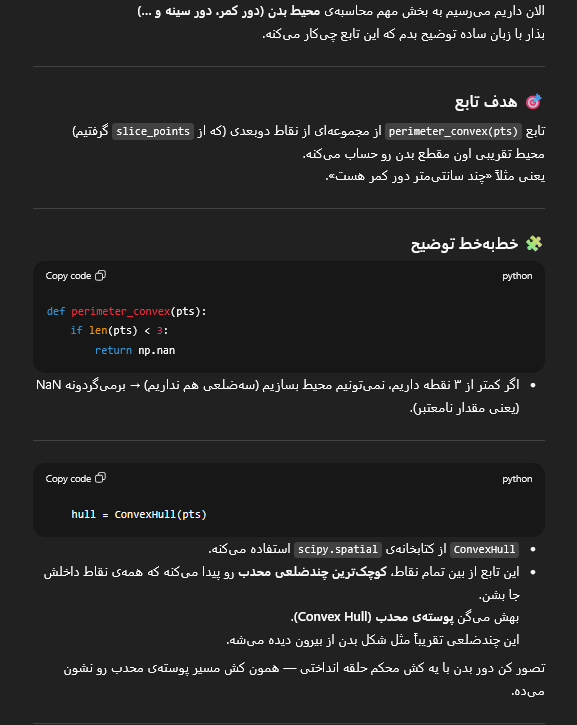
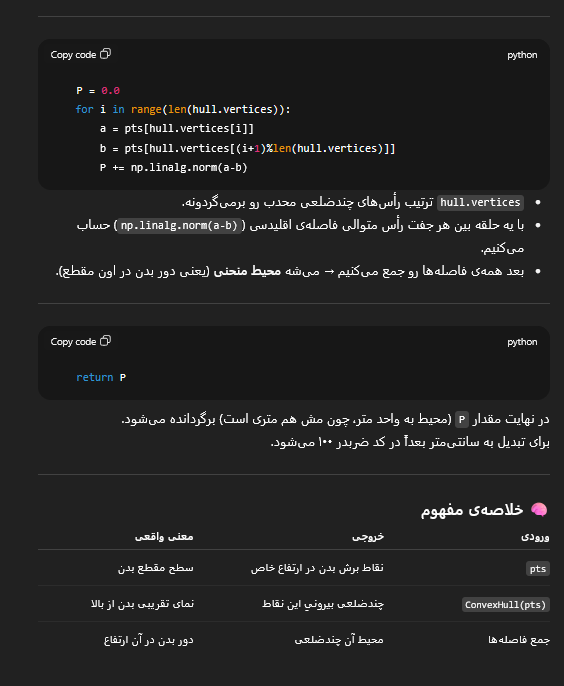
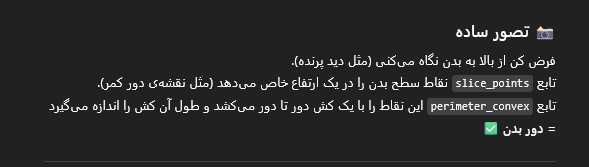

In [11]:
# def scan_perimeter_between(vertices, y_min, y_max, step=0.005):
#     if y_max <= y_min:
#         return np.empty((0, 2), dtype=float)
#     ys = np.arange(y_min, y_max, step)
#     if ys.size == 0:
#         ys = np.linspace(y_min, y_max, 3)  # حداقل 3 نمونه
#     vals = []
#     for y0 in ys:
#         pts = slice_points(vertices, y0)
#         vals.append([y0, perimeter_convex(pts)])
#     return np.asarray(vals, dtype=float)  # شکل [N,2]

def scan_perimeter_between(vertices, y_min, y_max, step=0.005):
    if y_max <= y_min:
        return np.empty((0, 2))
    ys = np.arange(y_min, y_max, step)
    if ys.size == 0:
        ys = np.linspace(y_min, y_max, 3)
    vals = []
    for y0 in ys:
        pts = slice_points(vertices, y0)
        vals.append([y0, perimeter_convex(pts)])
    return np.asarray(vals, float)


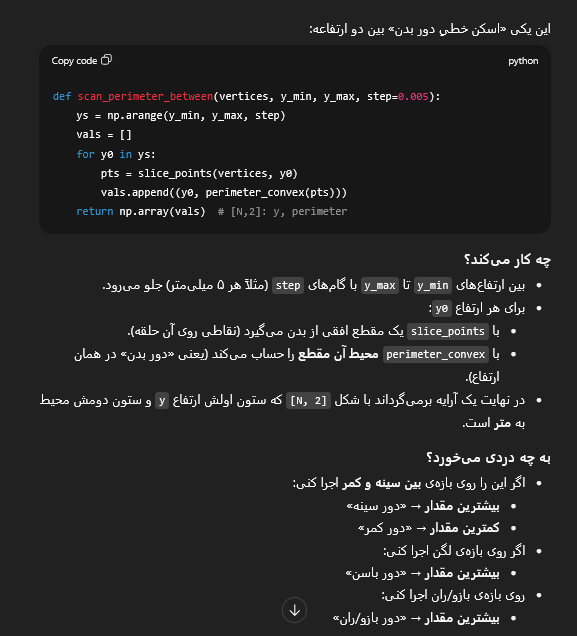
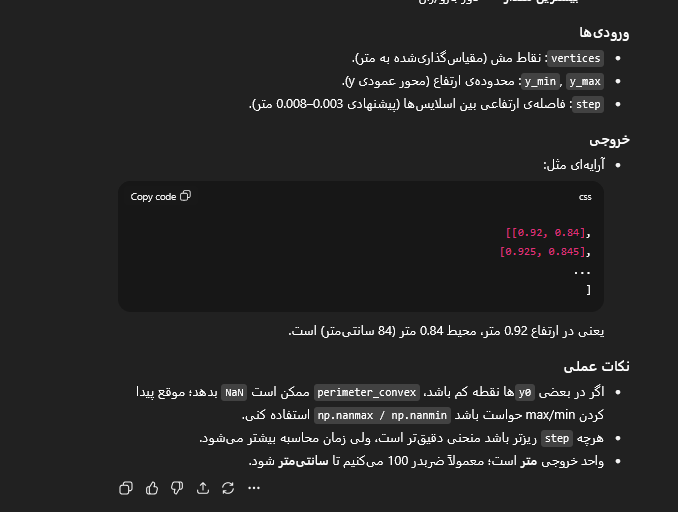

In [12]:
J = {
    "pelvis": 0,
    "left_hip": 1, "right_hip": 2,
    "spine1": 3, "spine2": 6,
    "neck": 12, "head": 15,
    "left_shoulder": 16, "right_shoulder": 17,
    "left_elbow": 18, "right_elbow": 19,
    "left_wrist": 20, "right_wrist": 21,
    "left_knee": 4, "right_knee": 5,
    "left_ankle": 7, "right_ankle": 8,
    "left_toe": 9, "right_toe": 10,
}

In [13]:
def avg_y_mp(joints, mp, a, b):
    return 0.5 * (joints[mp[a],1] + joints[mp[b],1])


In [14]:
def ground_y_mp(joints, vertices, mp):
    ankles = float(min(joints[mp["left_ankle"],1], joints[mp["right_ankle"],1]))
    floor  = float(vertices[:,1].min())
    return min(ankles, floor)

In [15]:
# def measure_core(vertices, joints):
#     res = {}
#     mp = choose_joint_map_smart(joints)
#     print(">>> Joint mapping selected:", mp)
#
#     # --- محدوده‌های تنه
#     y_neck   = float(joints[mp["neck"], 1])
#     y_pelvis = float(joints[mp["pelvis"], 1])
#     y_mid    = 0.5 * (y_neck + y_pelvis)
#
#     # 1) قفسهٔ سینه: بیشینهٔ محیط بین زیر بغل و میانهٔ تنه
#     scan_chest = scan_perimeter_between(vertices, y_mid, y_neck - 0.02, step=0.004)
#     if scan_chest.size:
#         # میانگین موضعی برای پایداری
#         idx = int(np.nanargmax(scan_chest[:, 1]))
#         y_chest = float(scan_chest[idx, 0])
#         win = scan_chest[max(0, idx-2): idx+3, 1]
#         res["chest_circum_cm"] = float(np.nanmean(win) * 100.0)
#     else:
#         res["chest_circum_cm"] = np.nan
#
#     # 2) کمر: کمینهٔ محیط بین قفسه سینه و لگن
#     scan_waist = scan_perimeter_between(vertices, y_pelvis + 0.03, y_mid, step=0.004)
#     if scan_waist.size:
#         idx = int(np.nanargmin(scan_waist[:, 1]))
#         win = scan_waist[max(0, idx-2): idx+3, 1]
#         res["waist_circum_cm"] = float(np.nanmean(win) * 100.0)
#     else:
#         res["waist_circum_cm"] = np.nan
#
#     # 3) باسن: بیشینهٔ محیط نزدیک لگن
#     scan_hip = scan_perimeter_between(vertices, y_pelvis - 0.10, y_pelvis + 0.04, step=0.004)
#     if scan_hip.size:
#         idx = int(np.nanargmax(scan_hip[:, 1]))
#         win = scan_hip[max(0, idx-2): idx+3, 1]
#         res["hip_circum_cm"] = float(np.nanmean(win) * 100.0)
#     else:
#         res["hip_circum_cm"] = np.nan
#
#     # --- بازو (مقطع عمود بر محور شانه→آرنج)
#     L_sh = joints[mp["left_shoulder"]];  L_el = joints[mp["left_elbow"]]
#     R_sh = joints[mp["right_shoulder"]]; R_el = joints[mp["right_elbow"]]
#
#     c_bicep_L = orth_slice_along_segment(vertices, L_sh, L_el, t=0.5, radius=0.07, tol=0.006)
#     c_bicep_R = orth_slice_along_segment(vertices, R_sh, R_el, t=0.5, radius=0.07, tol=0.006)
#
#     res["upperarm_circum_L_cm"] = float(c_bicep_L * 100.0) if np.isfinite(c_bicep_L) else np.nan
#     res["upperarm_circum_R_cm"] = float(c_bicep_R * 100.0) if np.isfinite(c_bicep_R) else np.nan
#     res["upperarm_circum_cm"]   = float(np.nanmean([res["upperarm_circum_L_cm"], res["upperarm_circum_R_cm"]]))
#
#     # --- ران (مقطع عمود بر محور لگن→زانو)
#     L_hp = joints[mp["left_hip"]];   L_kn = joints[mp["left_knee"]]
#     R_hp = joints[mp["right_hip"]];  R_kn = joints[mp["right_knee"]]
#
#     # c_thigh_L = orth_slice_along_segment(vertices, L_hp, L_kn, t=0.5, radius=0.12, tol=0.006)
#     # c_thigh_R = orth_slice_along_segment(vertices, R_hp, R_kn, t=0.5, radius=0.12, tol=0.006)
#
#     candidates_L = [
#     orth_slice_along_segment(vertices, L_hp, L_kn, t=0.40, radius=0.16, tol=0.010),
#     orth_slice_along_segment(vertices, L_hp, L_kn, t=0.50, radius=0.16, tol=0.010),
#     orth_slice_along_segment(vertices, L_hp, L_kn, t=0.60, radius=0.16, tol=0.010),
#     ]
#     candidates_R = [
#     orth_slice_along_segment(vertices, R_hp, R_kn, t=0.40, radius=0.16, tol=0.010),
#     orth_slice_along_segment(vertices, R_hp, R_kn, t=0.50, radius=0.16, tol=0.010),
#     orth_slice_along_segment(vertices, R_hp, R_kn, t=0.60, radius=0.16, tol=0.010),
#     ]
#
#     def best_perimeter(vals):
#         vals = [v for v in vals if np.isfinite(v)]
#         return (max(vals) if vals else np.nan)
#     c_thigh_L = best_perimeter(candidates_L)
#     c_thigh_R = best_perimeter(candidates_R)
#
#
#     res["thigh_circum_L_cm"] = float(c_thigh_L * 100.0) if np.isfinite(c_thigh_L) else np.nan
#     res["thigh_circum_R_cm"] = float(c_thigh_R * 100.0) if np.isfinite(c_thigh_R) else np.nan
#     res["thigh_circum_cm"]   = float(np.nanmean([res["thigh_circum_L_cm"], res["thigh_circum_R_cm"]]))
#
#
#
#     y_side_waist = avg_y_mp(joints, mp, "left_hip", "right_hip") + 0.02
#     y_ground = ground_y_mp(joints, vertices, mp)
#     res["pants_outseam_cm"] = float(max(0.0, (y_side_waist - y_ground)) * 100.0)
#
#     # --- قد آستین: (شانه→آرنج→مچ) با mp نهایی
#     L_len = np.linalg.norm(L_sh - L_el) + np.linalg.norm(L_el - joints[mp["left_wrist"]])
#     R_len = np.linalg.norm(R_sh - R_el) + np.linalg.norm(R_el - joints[mp["right_wrist"]])
#     res["sleeve_len_cm"] = float(np.nanmean([L_len, R_len]) * 100.0)
#
#     # --- قد بلوز / پیراهن
#     y_neck_base = y_neck
#     y_hip_top   = y_pelvis + 0.02
#     res["top_len_cm"]  = float((y_neck_base - y_hip_top) * 100.0)
#
#     y_floor_mesh = float(vertices[:,1].min())
#     res["gown_len_cm"] = float(max(0.0, (y_neck - y_floor_mesh)) * 100.0)
#     # res["gown_len_cm"] = float((y_neck_base - y_ground) * 100.0)
#
#     return res

def measure_core(vertices, joints):
    res = {}
    mp, s_guess, o_guess = choose_joint_map_auto(joints, vertices)
    print(">>> picked mp:", mp, "| sleeve_guess:", round(s_guess,1), "| outseam_guess:", round(o_guess,1))

    y_neck   = float(joints[mp["neck"], 1])
    y_pelvis = float(joints[mp["pelvis"], 1])
    y_mid    = 0.5 * (y_neck + y_pelvis)

    # --- قفسه سینه / کمر / باسن
    scan_chest = scan_perimeter_between(vertices, y_mid, y_neck - 0.02, step=0.004)
    scan_waist = scan_perimeter_between(vertices, y_pelvis + 0.03, y_mid, step=0.004)
    scan_hip   = scan_perimeter_between(vertices, y_pelvis - 0.10, y_pelvis + 0.04, step=0.004)
    res["chest_circum_cm"] = float(np.nanmax(scan_chest[:,1])*100) if scan_chest.size else np.nan
    res["waist_circum_cm"] = float(np.nanmin(scan_waist[:,1])*100) if scan_waist.size else np.nan
    res["hip_circum_cm"]   = float(np.nanmax(scan_hip[:,1])*100)   if scan_hip.size else np.nan

    # --- بازو
    L_sh, L_el = joints[mp["left_shoulder"]], joints[mp["left_elbow"]]
    R_sh, R_el = joints[mp["right_shoulder"]], joints[mp["right_elbow"]]
    def best_circ(p0,p1):
        vals = [orth_slice_along_segment(vertices, p0, p1, t=t, radius=0.10, tol=0.010)
                for t in (0.35, 0.45, 0.55, 0.65)]
        vals = [v for v in vals if np.isfinite(v)]
        return max(vals) if vals else np.nan
    cL = best_circ(L_sh, L_el); cR = best_circ(R_sh, R_el)
    res["upperarm_circum_L_cm"] = float(cL*100) if np.isfinite(cL) else np.nan
    res["upperarm_circum_R_cm"] = float(cR*100) if np.isfinite(cR) else np.nan
    res["upperarm_circum_cm"]   = float(np.nanmean([res["upperarm_circum_L_cm"], res["upperarm_circum_R_cm"]]))

    # --- ران
    L_hp, L_kn = joints[mp["left_hip"]], joints[mp["left_knee"]]
    R_hp, R_kn = joints[mp["right_hip"]], joints[mp["right_knee"]]
    def best_thigh(p0,p1):
        vals = [orth_slice_along_segment(vertices, p0, p1, t=t, radius=0.18, tol=0.012)
                for t in (0.40, 0.50, 0.60)]
        vals = [v for v in vals if np.isfinite(v)]
        return max(vals) if vals else np.nan
    cTL = best_thigh(L_hp, L_kn); cTR = best_thigh(R_hp, R_kn)
    res["thigh_circum_L_cm"] = float(cTL*100) if np.isfinite(cTL) else np.nan
    res["thigh_circum_R_cm"] = float(cTR*100) if np.isfinite(cTR) else np.nan
    res["thigh_circum_cm"]   = float(np.nanmean([res["thigh_circum_L_cm"], res["thigh_circum_R_cm"]]))

    # --- قد شلوار و قد آستین
    waist_y  = 0.5*(joints[mp["left_hip"],1] + joints[mp["right_hip"],1]) + 0.02
    ankle_y  = float(min(joints[mp["left_ankle"],1], joints[mp["right_ankle"],1]))
    ground_y = ankle_y - 0.03
    res["pants_outseam_cm"] = float(max(0.0, (waist_y - ground_y)) * 100.0)
    L_len = np.linalg.norm(L_sh - L_el) + np.linalg.norm(L_el - joints[mp["left_wrist"]])
    R_len = np.linalg.norm(R_sh - R_el) + np.linalg.norm(R_el - joints[mp["right_wrist"]])
    res["sleeve_len_cm"] = float(np.nanmean([L_len, R_len]) * 100.0)

    # --- قد بلوز و پیراهن
    res["top_len_cm"]  = float((y_neck - (y_pelvis + 0.02)) * 100.0)
    res["gown_len_cm"] = float(max(0.0, (y_neck - (ankle_y - 0.03))) * 100.0)
    return res

In [16]:
def fuse_shape(betas_list):
    return np.mean(np.stack(betas_list, axis=0), axis=0)


In [17]:
def measure_pipeline(smpl_output_front, smpl_output_tpose, smpl_output_side,
                     user_height_cm, gender, width_scale=1.0):
    vertices = smpl_output_tpose["vertices"]
    joints   = smpl_output_tpose["joints"]
    vertices, joints, s = rescale_to_user_height(
        vertices, joints, user_height_cm / 100.0, width_scale=width_scale)
    print("Scaled body height (m):", body_height_y(vertices))
    res = measure_core(vertices, joints)
    res.update({
        "gender": gender,
        "user_height_cm": user_height_cm,
        "scale_factor": s,
        "width_scale": width_scale,
    })
    return res

In [18]:
smpl_output_tpose = np.load("logs/demo/img_triplet_/tmp_tpose_smpl.npz", allow_pickle=True)

In [19]:
smpl_output_front = np.load("logs/demo/img_triplet_/tmp_front_smpl.npz", allow_pickle=True)

In [20]:
smpl_output_side  = np.load("logs/demo/img_triplet_/tmp_side_smpl.npz", allow_pickle=True)

In [21]:
res = measure_pipeline(
    smpl_output_front, smpl_output_tpose, smpl_output_side,
    user_height_cm=175, gender="male", width_scale=0.75
)

Scaled body height (m): 1.75
>>> picked mp: {'pelvis': 0, 'left_hip': 1, 'right_hip': 2, 'left_knee': 3, 'right_knee': 4, 'left_ankle': 5, 'right_ankle': 6, 'neck': 12, 'left_shoulder': 13, 'right_shoulder': 14, 'left_elbow': 15, 'right_elbow': 16, 'left_wrist': 17, 'right_wrist': 18} | sleeve_guess: 137.6 | outseam_guess: 5.3


In [22]:
print(json.dumps(res, ensure_ascii=False, indent=2))

{
  "chest_circum_cm": 67.63530448079109,
  "waist_circum_cm": 63.71574136428535,
  "hip_circum_cm": 150.03935396671295,
  "upperarm_circum_L_cm": 41.21762697172552,
  "upperarm_circum_R_cm": 42.586532898046435,
  "upperarm_circum_cm": 41.902079934885975,
  "thigh_circum_L_cm": 28.9562634778679,
  "thigh_circum_R_cm": 22.540883356249623,
  "thigh_circum_cm": 25.74857341705876,
  "pants_outseam_cm": 5.274157524108891,
  "sleeve_len_cm": 137.6083254814148,
  "top_len_cm": 67.45149451494217,
  "gown_len_cm": 57.537101089954376,
  "gender": "male",
  "user_height_cm": 175,
  "scale_factor": 0.9262917880868163,
  "width_scale": 0.75
}


In [23]:
import numpy as np
data = np.load(r'.\logs\demo\img_triplet_\tmp_tpose_smpl.npz')
v = data['vertices']
print(v.min(axis=0), v.max(axis=0))


[-0.4676597  -1.1325947  -0.33438376] [0.5100414 0.7566588 0.2401138]
